<a href="https://colab.research.google.com/github/JefersonAlexander/segmentbraintumor/blob/main/03_arquitectura_de_linea_de_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
import os
import shutil
import tarfile
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Flatten
from tensorflow.keras.layers import Dropout, Lambda
from tensorflow.keras.layers import Conv2D, Conv2DTranspose
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import concatenate
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau, CSVLogger
from tensorflow.keras import backend as K
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall, MeanIoU

%matplotlib inline
%load_ext tensorboard

from sklearn.datasets import *

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


## Mount Google Drive to access preprocessed datasets

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Check if a GPU is available for TensorFlow training

In [4]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"SUCCESS: {len(gpus)} GPU(s) detected!")
    print(f"Device Name: {gpus[0].name}")
else:
    print(" ERROR: No GPU detected. You are running on CPU.")

SUCCESS: 1 GPU(s) detected!
Device Name: /physical_device:GPU:0


## Extract the preprocessed dataset from the ZIP file into the working directory

In [5]:
import zipfile
import os

# Path to the ZIP file containing the preprocessed dataset
zip_path = "/content/drive/MyDrive/segmentatioImage/processed_unet.zip"

# Directory where the dataset will be extracted
base_path = "/content/processed_unet"

# Create the destination folder if it does not exist
os.makedirs(base_path, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(base_path)

print("Dataset extracted successfully")

Dataset extracted successfully


## Display the files and folders extracted in the dataset directory

In [6]:
print(os.listdir(base_path))

['masks', 'images']


In [7]:
IMAGES_DIR = os.path.join("/content/processed_unet/images")
MASKS_DIR = os.path.join("/content/processed_unet/masks")


## Prepare and split the dataset into training, validation, and test sets based on patient IDs

In [8]:
# Split the dataset into training, validation, and test sets based on patient IDs
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence
import os
import numpy as np

# =========================
# 1. List image and mask files
# =========================

images_list = sorted(os.listdir(IMAGES_DIR))
masks_list = sorted(os.listdir(MASKS_DIR))

# Extract unique patient IDs
patient_ids = sorted(list(set([
    "_".join(img.split("_")[:2])
    for img in images_list
])))

print("Total patients:", len(patient_ids))


# =========================
# 2. Split patients into train, validation, and test sets
# =========================

train_patients, temp_patients = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.5,
    random_state=42
)

print("Train patients:", len(train_patients))
print("Validation patients:", len(val_patients))
print("Test patients:", len(test_patients))


# =========================
# 3. Create image and mask lists for each split
# =========================

train_images, train_masks = [], []
val_images, val_masks = [], []
test_images, test_masks = [], []

for img_name, mask_name in zip(images_list, masks_list):

    patient_id = "_".join(img_name.split("_")[:2])

    if patient_id in train_patients:
        train_images.append(img_name)
        train_masks.append(mask_name)

    elif patient_id in val_patients:
        val_images.append(img_name)
        val_masks.append(mask_name)

    elif patient_id in test_patients:
        test_images.append(img_name)
        test_masks.append(mask_name)

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

Total patients: 200
Train patients: 160
Validation patients: 20
Test patients: 20
Train images: 9523
Validation images: 1207
Test images: 1261


## Count the total number of images and segmentation masks in the dataset

In [9]:
num_images = len(os.listdir(IMAGES_DIR))
num_masks = len(os.listdir(MASKS_DIR))

print(f"Cantidad de imágenes: {num_images}")
print(f"Cantidad de máscaras: {num_masks}")

Cantidad de imágenes: 11991
Cantidad de máscaras: 11991


## Custom data generator for loading and preprocessing brain tumor MRI images and segmentation masks in batches

In [10]:
class BrainTumorGenerator(Sequence):

    def __init__(
        self,
        image_files,
        mask_files,
        images_dir,
        masks_dir,
        batch_size=16,
        shuffle=True
    ):
        self.image_files = image_files
        self.mask_files = mask_files
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.indexes = np.arange(len(self.image_files))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_files) / self.batch_size))

    def __getitem__(self, index):

        batch_indexes = self.indexes[
            index * self.batch_size:(index + 1) * self.batch_size
        ]

        batch_images = []
        batch_masks = []

        for i in batch_indexes:

            img = np.load(
                os.path.join(self.images_dir, self.image_files[i])
            )

            mask = np.load(
                os.path.join(self.masks_dir, self.mask_files[i])
            )

            # images
            img = img.astype(np.float32) / 255.0

            # multiclass mask
            mask = mask.astype(np.uint8)
            mask[mask == 4] = 3

            # add chanel to the mask
            mask = np.expand_dims(mask, axis=-1)

            batch_images.append(img)
            batch_masks.append(mask)

        X = np.array(batch_images, dtype=np.float32)
        y = np.array(batch_masks, dtype=np.uint8)

        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

# Create data generators for training, validation, and testing datasets

In [11]:
train_generator = BrainTumorGenerator(
    train_images,
    train_masks,
    IMAGES_DIR,
    MASKS_DIR,
    batch_size=16,
    shuffle=True
)

val_generator = BrainTumorGenerator(
    val_images,
    val_masks,
    IMAGES_DIR,
    MASKS_DIR,
    batch_size=16,
    shuffle=False
)

test_generator = BrainTumorGenerator(
    test_images,
    test_masks,
    IMAGES_DIR,
    MASKS_DIR,
    batch_size=16,
    shuffle=False
)

# Define Dice coefficient metric and Dice loss function for multi-class image segmentation

In [51]:
@tf.keras.utils.register_keras_serializable()
def dice_coef(y_true, y_pred, smooth=1e-7):
    '''
    Dice coefficient for 10 categories. Ignores background pixel label 0
    Pass to model as metric during compile statement
    '''
    y_true_f = K.flatten(K.one_hot(K.cast(y_true, 'int32'), num_classes=4)[...,1:])
    y_pred_f = K.flatten(y_pred[...,1:])
    intersect = K.sum(y_true_f * y_pred_f, axis=-1)
    denom = K.sum(y_true_f + y_pred_f, axis=-1)
    return K.mean((2. * intersect / (denom + smooth)))

@tf.keras.utils.register_keras_serializable()
def dice_coef_9cat_loss(y_true, y_pred):
    '''
    Dice loss to minimize. Pass to model as loss during compile statement
    '''
    return 1 - dice_coef(y_true, y_pred)

In [52]:
@tf.keras.utils.register_keras_serializable()
def mean_iou(y_true, y_pred, smooth=1e-7):

    # Convert predictions from probabilities to labels
    y_pred = tf.argmax(y_pred, axis=-1)

    # Remove last dimension from ground truth
    y_true = tf.squeeze(y_true, axis=-1)

    # Convert to int32
    y_true = tf.cast(y_true, tf.int32)
    y_pred = tf.cast(y_pred, tf.int32)

    iou_scores = []

    # Ignore background class (0)
    for class_id in range(1, 4):

        true_class = tf.equal(y_true, class_id)
        pred_class = tf.equal(y_pred, class_id)

        intersection = tf.reduce_sum(
            tf.cast(true_class & pred_class, tf.float32)
        )

        union = tf.reduce_sum(
            tf.cast(true_class | pred_class, tf.float32)
        )

        iou = (intersection + smooth) / (union + smooth)

        iou_scores.append(iou)

    return tf.reduce_mean(iou_scores)

# Define the U-Net model architecture

In [44]:
def get_model_UNET(IMG_HEIGHT=128, IMG_WIDTH=128, IMG_CHANNELS=4, N_CLASSES=4,kernels=16):

    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

    c1 = Conv2D(kernels, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(kernels, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(kernels*2, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(kernels*2, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(kernels*4, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(kernels*4, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(kernels*8, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(kernels*8, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D((2, 2))(c4)


    c5 = Conv2D(kernels*16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(kernels*16, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c5)

    u6 = Conv2DTranspose(kernels*8, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])


    c6 = Conv2D(kernels*8, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(kernels*8, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = Conv2DTranspose(kernels*4, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(kernels*4, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(kernels*4, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = Conv2DTranspose(kernels*2, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(kernels*2, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(kernels*2, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = Conv2DTranspose(kernels, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(kernels, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(kernels, (3, 3), activation='elu', kernel_initializer='he_normal', padding='same')(c9)

    outputs = Conv2D(N_CLASSES, (1, 1), activation='softmax')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=[dice_coef,mean_iou]
    )

    return model

In [45]:
model = get_model_UNET()
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 128, 128,  │        592 │ input_layer_11[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_45          │ (None, 128, 128,  │          0 │ conv2d_95[0][0]   │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 128, 128,  │      2,320 │ dropout_45[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 64, 64,    │          0 │ conv2d_96[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_20… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_46          │ (None, 64, 64,    │          0 │ conv2d_97[0][0]   │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 64, 64,    │      9,248 │ dropout_46[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 32, 32,    │          0 │ conv2d_98[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_99 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_21… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_47          │ (None, 32, 32,    │          0 │ conv2d_99[0][0]   │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_100 (Conv2D) │ (None, 32, 32,    │     36,928 │ dropout_47[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 16, 16,    │          0 │ conv2d_100[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_101 (Conv2D) │ (None, 16, 16,    │     73,856 │ max_pooling2d_22… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_48          │ (None, 16, 16,    │          0 │ conv2d_101[0][0]  │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_102 (Conv2D) │ (None, 16, 16,    │    147,584 │ dropout_48[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_23    │ (None, 8, 8, 128) │          0 │ conv2d_102[0][0]

 Total params: 1,941,300 (7.41 MB)

 Trainable params: 1,941,300 (7.41 MB)

 Non-trainable params: 0 (0.00 B)

# Define training callbacks for early stopping, model checkpointing, learning rate reduction, and training logging

In [41]:
earlystopper = EarlyStopping(
    monitor='val_dice_coef',
    mode='max',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

checkpointer = ModelCheckpoint(
    'model-best.keras',
    verbose=1,
    save_best_only=True,
    monitor='val_dice_coef',
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

csv_logger = CSVLogger('training_log.csv')

# Train the U-Net model using the training and validation generators

In [62]:
modeltrain = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[
        earlystopper,
        checkpointer,
        reduce_lr
    ]
)

Epoch 1/30
595/596 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - dice_coef: 0.8893 - loss: 0.0078 - mean_iou: 0.8444
Epoch 1: val_dice_coef did not improve from 0.73673
596/596 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - dice_coef: 0.8900 - loss: 0.0078 - mean_iou: 0.8450 - val_dice_coef: 0.7344 - val_loss: 0.0402 - val_mean_iou: 0.5803 - learning_rate: 6.2500e-05
Epoch 2/30
595/596 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - dice_coef: 0.8902 - loss: 0.0077 - mean_iou: 0.8443
Epoch 2: val_dice_coef did not improve from 0.73673
596/596 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - dice_coef: 0.8904 - loss: 0.0078 - mean_iou: 0.8449 - val_dice_coef: 0.7337 - val_loss: 0.0412 - val_mean_iou: 0.5798 - learning_rate: 6.2500e-05
Epoch 3/30
595/596 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - dice_coef: 0.8905 - loss: 0.0078 - mean_iou: 0.8459
Epoch 3: val_dice_coef did not improve from 0.73673

Epoch 3: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
596/596 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - dice_coef: 0.8908 -

# Evaluate the trained model on the test dataset and display performance metrics

In [63]:
best_epoch = np.argmax(modeltrain.history['val_dice_coef'])

print(f"Best Epoch: {best_epoch + 1}")

print(f"Train Loss: {modeltrain.history['loss'][best_epoch]:.4f}")
print(f"Validation Loss: {modeltrain.history['val_loss'][best_epoch]:.4f}")

print(f"Train Dice: {modeltrain.history['dice_coef'][best_epoch]:.4f}")
print(f"Validation Dice: {modeltrain.history['val_dice_coef'][best_epoch]:.4f}")

Best Epoch: 5
Train Loss: 0.0076
Validation Loss: 0.0402
Train Dice: 0.8918
Validation Dice: 0.7370


# Load the best saved model and evaluate its performance on the test dataset


In [65]:
best_model = load_model(
    'model-best.keras',
    custom_objects={
        'dice_coef': dice_coef
    }
)

In [66]:
resultstest = best_model.evaluate(test_generator)

for name, value in zip(best_model.metrics_names, resultstest ):
    print(f"{name}: {value:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - dice_coef: 0.7196 - loss: 0.0415 - mean_iou: 0.5884
loss: 0.0415
compile_metrics: 0.7196


# Compute multi-class Dice scores and visualize MRI slices with ground truth and predicted tumor segmentations

In [67]:
def multiclass_dice_score(y_true, y_pred, num_classes=4, smooth=1e-6, include_background=True):
    dice_scores = []

    start_class = 0 if include_background else 1

    for class_id in range(start_class, num_classes):
        y_true_class = (y_true == class_id).astype(np.uint8)
        y_pred_class = (y_pred == class_id).astype(np.uint8)

        intersection = np.sum(y_true_class * y_pred_class)

        dice = (2.0 * intersection + smooth) / (
            np.sum(y_true_class) + np.sum(y_pred_class) + smooth
        )

        dice_scores.append(dice)

    return np.mean(dice_scores), dice_scores


def visualize_slice_80(model, patient_id, slice_num):
    image_name = f"{patient_id}_slice_{slice_num}.npy"

    img = np.load(os.path.join(IMAGES_DIR, image_name))
    img_input = img.astype(np.float32) / 255.0

    true_mask = np.load(os.path.join(MASKS_DIR, image_name)).astype(np.uint8)
    true_mask[true_mask == 4] = 3

    pred_mask = model.predict(
        np.expand_dims(img_input, axis=0),
        verbose=0
    )[0]

    pred_classes = np.argmax(pred_mask, axis=-1).astype(np.uint8)

    dice_mean, dice_per_class = multiclass_dice_score(
        true_mask,
        pred_classes,
        num_classes=4,
        include_background=False
    )

    print("True mask classes:", np.unique(true_mask))
    print("Predicted classes:", np.unique(pred_classes))

    print("Pixels clase 3 reales:",
          np.sum(true_mask == 3))

    print("Pixels clase 3 predichos:",
      np.sum(pred_classes == 3))

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img[:, :, 0], cmap="gray")
    axes[0].imshow(true_mask, cmap="jet", alpha=0.5, vmin=0, vmax=4)
    axes[0].set_title("Overlay Original")
    axes[0].axis("off")

    axes[1].imshow(true_mask, cmap="jet", vmin=0, vmax=4)
    axes[1].set_title("Original Segmentation")
    axes[1].axis("off")

    axes[2].imshow(pred_classes, cmap="jet", vmin=0, vmax=4)
    axes[2].set_title("Predicted Segmentation")
    axes[2].axis("off")

    axes[3].imshow(img[:, :, 0], cmap="gray")
    axes[3].imshow(pred_classes, cmap="jet", alpha=0.5, vmin=0, vmax=4)
    axes[3].set_title(f"Overlay Prediction\nMean Dice: {dice_mean:.4f}")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Mean Multiclass Dice: {dice_mean:.4f}")
    print(f"Dice clase 0: {dice_per_class[0]:.4f}")
    print(f"Dice clase 1: {dice_per_class[1]:.4f}")
    print(f"Dice clase 2: {dice_per_class[2]:.4f}")
    #print(f"Dice clase 3: {dice_per_class[3]:.4f}")



True mask classes: [0 1 2 3]
Predicted classes: [0 1 2 3]
Pixels clase 3 reales: 140
Pixels clase 3 predichos: 155


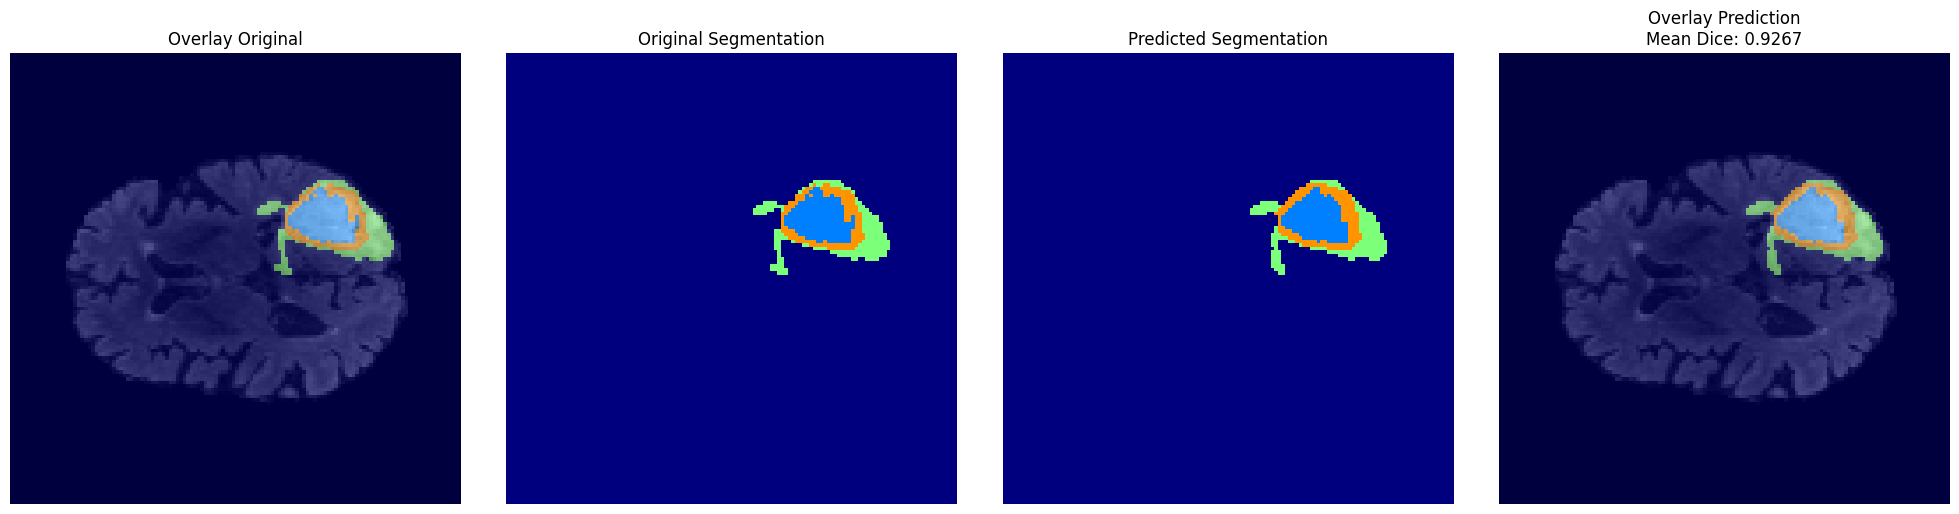

Mean Multiclass Dice: 0.9267
Dice clase 0: 0.9653
Dice clase 1: 0.9063
Dice clase 2: 0.9085


In [68]:
visualize_slice_80(model, "BraTS2021_00020",70)